In [1]:
from ax.service.ax_client import AxClient
import ax
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
experiment_folder = '2025-02-04'
iteration = 5

optimizer_path = f'../{experiment_folder}/optimizer/optimizer_{iteration}_loaded.json'
params_path = f'../{experiment_folder}/experiment_parameters.csv'

In [3]:
experiment_folder = 'smoketest_output'
iteration = 7

optimizer_path = f'../{experiment_folder}/optimizer/optimizer_smoketest_{iteration}_loaded.json'
params_path = f'../{experiment_folder}/experiment_parameters_smoketest.csv'

In [4]:
# import the optimizer
# Corrected code to load the optimizer
ax_client = AxClient.load_from_json_file(optimizer_path)

/Users/zeqing/opt/anaconda3/envs/drug-surfactant/lib/python3.10/site-packages/ax/storage/json_store/decoder.py:303: AxParameterWarning: `sort_values` is not specified for `ChoiceParameter` "drug". Defaulting to `False` for parameters of `ParameterType` STRING. To override this behavior (or avoid this warning), specify `sort_values` during `ChoiceParameter` construction.
  return _class(
[INFO 02-09 13:35:07] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.


In [5]:
# Get the experiment data in DataFrame format
df = ax_client.get_trials_data_frame()
df

[WARNING 02-09 13:35:07] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


,trial_index,arm_name,trial_status,generation_method,is_feasible,absorbance,obj_total_vol,s1,s2,s3,s4,s5,s6,s7,s8,drug
0,0,0_0,COMPLETED,Manual,True,0.0005,800.0000,0.0000,0.0000,0.0000,0.0000,550.0000,0.0000,250.0000,0.0000,IBP
1,1,1_0,COMPLETED,Manual,False,0.2000,820.0000,0.0000,0.0000,570.0000,0.0000,0.0000,0.0000,0.0000,250.0000,IBP
2,2,2_0,COMPLETED,Manual,True,0.0000,660.0000,0.0000,0.0000,165.0000,0.0000,495.0000,0.0000,0.0000,0.0000,IBP
3,3,3_0,COMPLETED,Manual,False,0.2000,560.0000,0.0000,370.0000,0.0000,190.0000,0.0000,0.0000,0.0000,0.0000,IBP
4,4,4_0,COMPLETED,Manual,True,0.0000,745.0000,670.0000,0.0000,0.0000,0.0000,0.0000,75.0000,0.0000,0.0000,IBP
5,5,5_0,COMPLETED,Manual,True,0.0000,710.0000,0.0000,320.0000,390.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP
6,6,6_0,COMPLETED,Manual,False,0.2000,515.0000,55.0000,0.0000,0.0000,460.0000,0.0000,0.0000,0.0000,0.0000,IBP
7,7,7_0,COMPLETED,Manual,True,0.0000,665.0000,75.0000,0.0000,590.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP
8,8,8_0,COMPLETED,Manual,False,0.2000,360.0000,260.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP
9,9,9_0,COMPLETED,Manual,True,0.0000,530.0000,0.0000,0.0000,0.0000,0.0000,515.0000,15.0000,0.0000,0.0000,IBP


In [6]:
exp_params = pd.read_csv(params_path)
exp_params_dict = dict(zip(exp_params.iloc[:, 0], exp_params.iloc[:, 1]))

exp_params_dict

{'NUM_ITERATIONS': '8',
 'TRIALS_PER_ITERATION': '4',
 'REPLICATES': '2',
 'SURFACTANT_VOL_REDUCTION (%)': '20.0',
 'DRUG_CHOICES': 'IBP',
 'ABSORBANCE_THRESHOLD': '0.06',
 'NUM_RANDOM_TRIALS': '9',
 'PUNISHMENT_FACTOR': '1',
 'DELAY_TIME': '0'}

In [7]:
def add_iteration_number(df, trials_per_iteration, num_random_trials):
    df = df.copy()
    df['iteration'] = 0
    mask = df['trial_index'] >= num_random_trials
    df.loc[mask, 'iteration'] = ((df.loc[mask, 'trial_index'] - num_random_trials) // trials_per_iteration) + 1
    return df

In [8]:
df = add_iteration_number(df, int(exp_params_dict['TRIALS_PER_ITERATION']), int(exp_params_dict['NUM_RANDOM_TRIALS']))
df

,trial_index,arm_name,trial_status,generation_method,is_feasible,absorbance,obj_total_vol,s1,s2,s3,s4,s5,s6,s7,s8,drug,iteration
0,0,0_0,COMPLETED,Manual,True,0.0005,800.0000,0.0000,0.0000,0.0000,0.0000,550.0000,0.0000,250.0000,0.0000,IBP,0
1,1,1_0,COMPLETED,Manual,False,0.2000,820.0000,0.0000,0.0000,570.0000,0.0000,0.0000,0.0000,0.0000,250.0000,IBP,0
2,2,2_0,COMPLETED,Manual,True,0.0000,660.0000,0.0000,0.0000,165.0000,0.0000,495.0000,0.0000,0.0000,0.0000,IBP,0
3,3,3_0,COMPLETED,Manual,False,0.2000,560.0000,0.0000,370.0000,0.0000,190.0000,0.0000,0.0000,0.0000,0.0000,IBP,0
4,4,4_0,COMPLETED,Manual,True,0.0000,745.0000,670.0000,0.0000,0.0000,0.0000,0.0000,75.0000,0.0000,0.0000,IBP,0
5,5,5_0,COMPLETED,Manual,True,0.0000,710.0000,0.0000,320.0000,390.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP,0
6,6,6_0,COMPLETED,Manual,False,0.2000,515.0000,55.0000,0.0000,0.0000,460.0000,0.0000,0.0000,0.0000,0.0000,IBP,0
7,7,7_0,COMPLETED,Manual,True,0.0000,665.0000,75.0000,0.0000,590.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP,0
8,8,8_0,COMPLETED,Manual,False,0.2000,360.0000,260.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP,0
9,9,9_0,COMPLETED,Manual,True,0.0000,530.0000,0.0000,0.0000,0.0000,0.0000,515.0000,15.0000,0.0000,0.0000,IBP,1


In [9]:
def add_success_column(df, threshold):
    df = df.copy()
    df['success'] = (df['absorbance'] < threshold).astype(int)
    return df

In [10]:
df = add_success_column(df, float(exp_params_dict['ABSORBANCE_THRESHOLD']))
df

,trial_index,arm_name,trial_status,generation_method,is_feasible,absorbance,obj_total_vol,s1,s2,s3,s4,s5,s6,s7,s8,drug,iteration,success
0,0,0_0,COMPLETED,Manual,True,0.0005,800.0000,0.0000,0.0000,0.0000,0.0000,550.0000,0.0000,250.0000,0.0000,IBP,0,1
1,1,1_0,COMPLETED,Manual,False,0.2000,820.0000,0.0000,0.0000,570.0000,0.0000,0.0000,0.0000,0.0000,250.0000,IBP,0,0
2,2,2_0,COMPLETED,Manual,True,0.0000,660.0000,0.0000,0.0000,165.0000,0.0000,495.0000,0.0000,0.0000,0.0000,IBP,0,1
3,3,3_0,COMPLETED,Manual,False,0.2000,560.0000,0.0000,370.0000,0.0000,190.0000,0.0000,0.0000,0.0000,0.0000,IBP,0,0
4,4,4_0,COMPLETED,Manual,True,0.0000,745.0000,670.0000,0.0000,0.0000,0.0000,0.0000,75.0000,0.0000,0.0000,IBP,0,1
5,5,5_0,COMPLETED,Manual,True,0.0000,710.0000,0.0000,320.0000,390.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP,0,1
6,6,6_0,COMPLETED,Manual,False,0.2000,515.0000,55.0000,0.0000,0.0000,460.0000,0.0000,0.0000,0.0000,0.0000,IBP,0,0
7,7,7_0,COMPLETED,Manual,True,0.0000,665.0000,75.0000,0.0000,590.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP,0,1
8,8,8_0,COMPLETED,Manual,False,0.2000,360.0000,260.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,IBP,0,0
9,9,9_0,COMPLETED,Manual,True,0.0000,530.0000,0.0000,0.0000,0.0000,0.0000,515.0000,15.0000,0.0000,0.0000,IBP,1,1


In [11]:
def plot_obj_total_vol(df, success_only=False, show_error_bars=False):
    import matplotlib.pyplot as plt
    if success_only:
        data = df[df['success'] == 1]
    else:
        data = df
    grouped = data.groupby('iteration')['obj_total_vol'].agg(['mean', 'std'])
    plt.figure(figsize=(10, 6))
    if show_error_bars:
        plt.bar(grouped.index, grouped['mean'], yerr=grouped['std'], capsize=5)
    else:
        plt.bar(grouped.index, grouped['mean'])
    plt.xlabel('Iteration')
    plt.ylabel('Mean obj_total_vol')
    title_suffix = ' (Success Only)' if success_only else ' (All Data)'
    if show_error_bars:
        title_suffix += ' (with error bars)'
    plt.title('Mean obj_total_vol by Iteration' + title_suffix)
    plt.show()

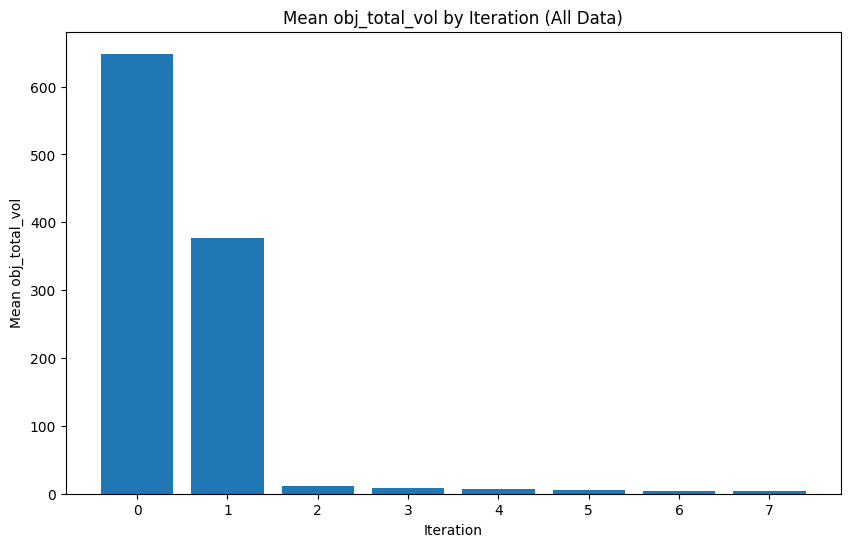

In [12]:
plot_obj_total_vol(df, success_only=False)

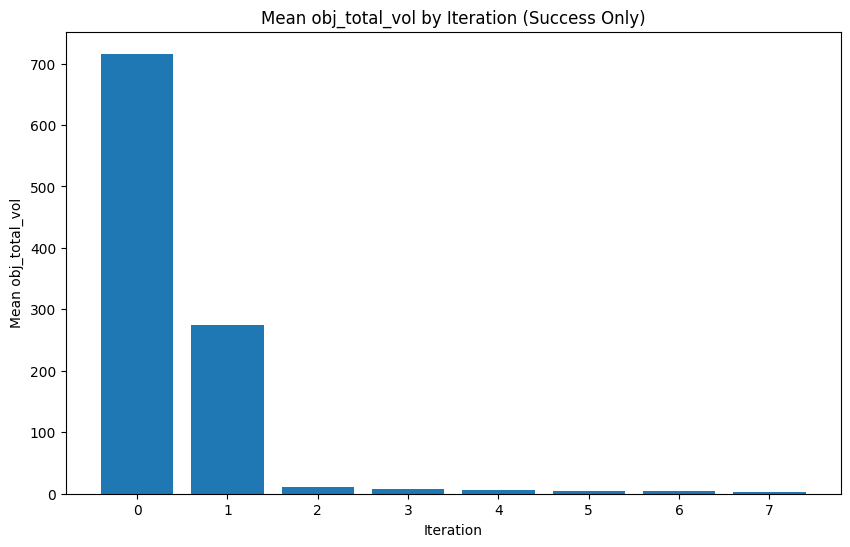

In [13]:
plot_obj_total_vol(df, success_only=True)

In [14]:
def plot_surfactant_table(df, cell_width=0.5, cell_height=0.2):
    surfactants = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
    iterations = sorted(df['iteration'].unique())
    grouped = df.groupby('iteration')[surfactants].mean().reindex(iterations)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.axis('off')
    
    all_values = grouped.values.flatten()
    max_val = np.max(all_values)
    
    def size_func(val):
        if max_val > 0:
            return (val / max_val) * 500
        else:
            return 250
    
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    for i, it in enumerate(iterations):
        for j, s in enumerate(surfactants):
            val = grouped.loc[it, s]
            y_pos = (len(surfactants) - 1 - j) * cell_height
            ax.scatter(i * cell_width, y_pos, s=size_func(val), c=colors[j], alpha=0.7, edgecolors='black')
    
    for i, it in enumerate(iterations):
        ax.text(i * cell_width, len(surfactants) * cell_height + 0.5, f'I{it}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    for j, s in enumerate(surfactants):
        y_pos = (len(surfactants) - 1 - j) * cell_height
        ax.text(-0.5 * cell_width, y_pos, s, ha='right', va='center', fontsize=12, fontweight='bold')
    
    ax.set_xlim(-0.5 * cell_width, (len(iterations) - 0.5) * cell_width)
    ax.set_ylim(-0.5 * cell_height, (len(surfactants) - 0.5) * cell_height)
    plt.show()

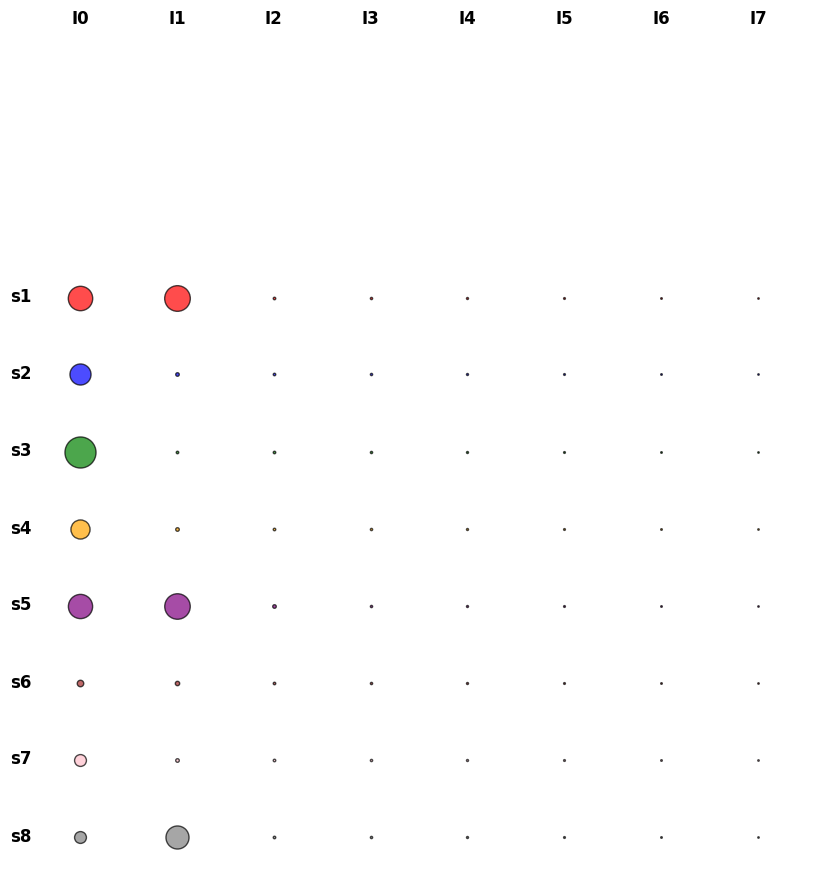

In [15]:
plot_surfactant_table(df)

In [16]:
def plot_surfactant_lines(df):
    surfactants = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
    iterations = sorted(df['iteration'].unique())
    grouped = df.groupby('iteration')[surfactants].mean().reindex(iterations)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    for j, s in enumerate(surfactants):
        ax.plot(iterations, grouped[s], label=s, color=colors[j], marker='o', linewidth=2)
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Mean Surfactant Concentration')
    ax.set_title('Surfactant Concentrations Over Iterations (Line Chart)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_surfactant_stacked_bars(df):
    surfactants = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
    iterations = sorted(df['iteration'].unique())
    grouped = df.groupby('iteration')[surfactants].mean().reindex(iterations)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    bottom = [0] * len(iterations)
    for j, s in enumerate(surfactants):
        ax.bar(iterations, grouped[s], bottom=bottom, label=s, color=colors[j], alpha=0.7)
        bottom = [b + v for b, v in zip(bottom, grouped[s])]
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Stacked Mean Surfactant Concentration')
    ax.set_title('Surfactant Concentrations Over Iterations (Stacked Bar Chart)')
    ax.legend()
    plt.show()

def plot_surfactant_grouped_bars(df):
    surfactants = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
    iterations = sorted(df['iteration'].unique())
    grouped = df.groupby('iteration')[surfactants].mean().reindex(iterations)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    bar_width = 0.1
    for j, s in enumerate(surfactants):
        positions = [i + j * bar_width for i in iterations]
        ax.bar(positions, grouped[s], width=bar_width, label=s, color=colors[j], alpha=0.7)
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Mean Surfactant Concentration')
    ax.set_title('Surfactant Concentrations Over Iterations (Grouped Bar Chart)')
    ax.set_xticks([i + 3.5 * bar_width for i in iterations])
    ax.set_xticklabels(iterations)
    ax.legend()
    plt.show()

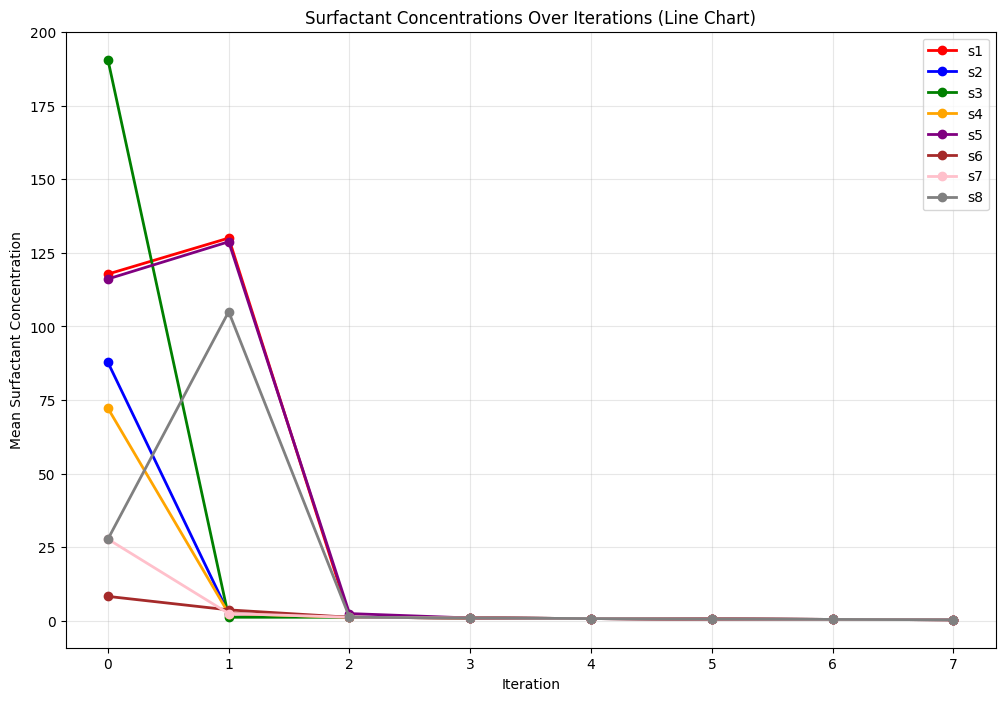

In [17]:
plot_surfactant_lines(df)

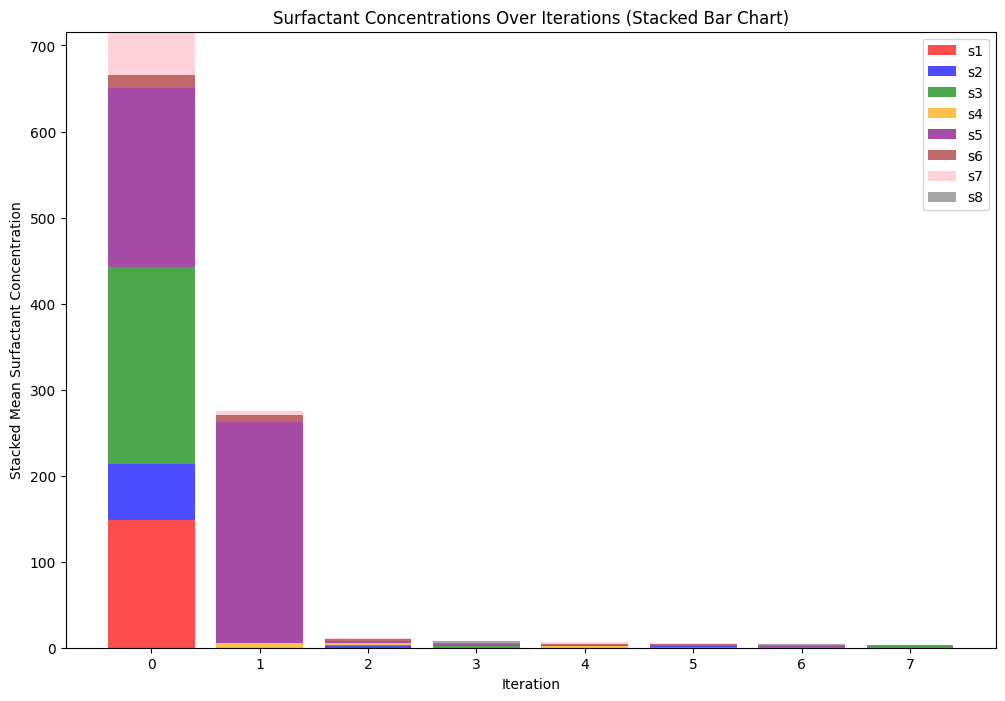

In [18]:
plot_surfactant_stacked_bars(df[df['success']==1])

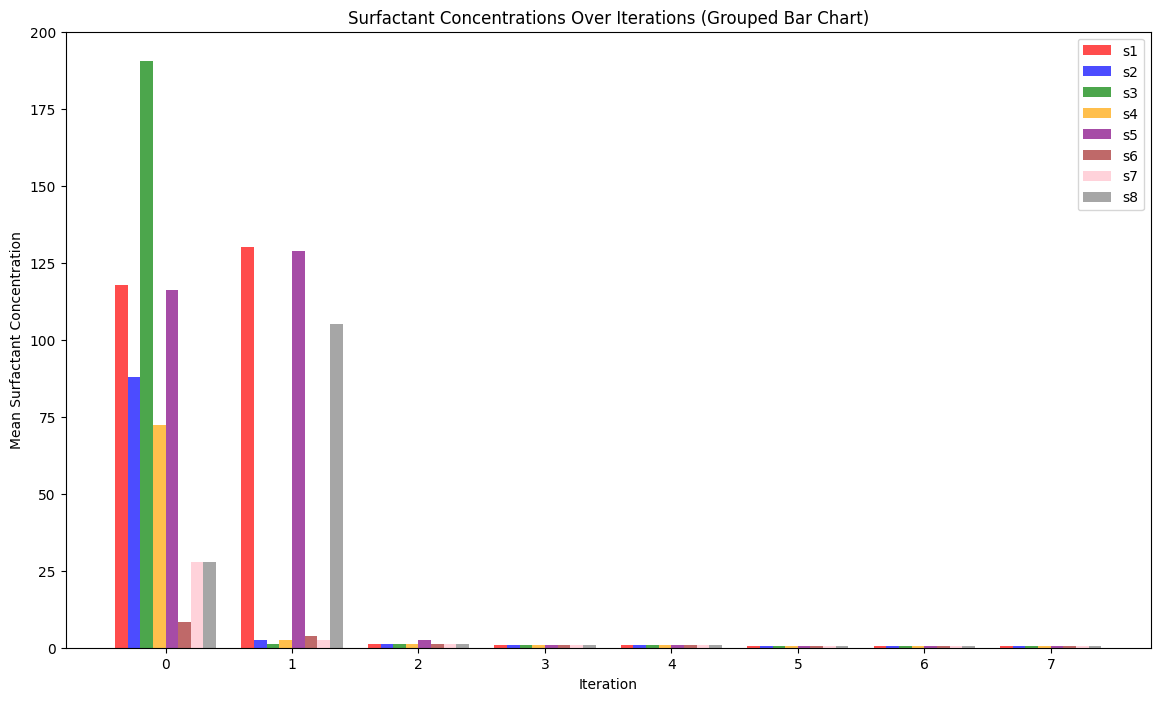

In [19]:
plot_surfactant_grouped_bars(df)